/tmp/ipython-input-4025263506.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = pd.Series(y, index=pd.date_range("2016-01-01", periods=120, freq="M"))


<Figure size 1000x800 with 0 Axes>

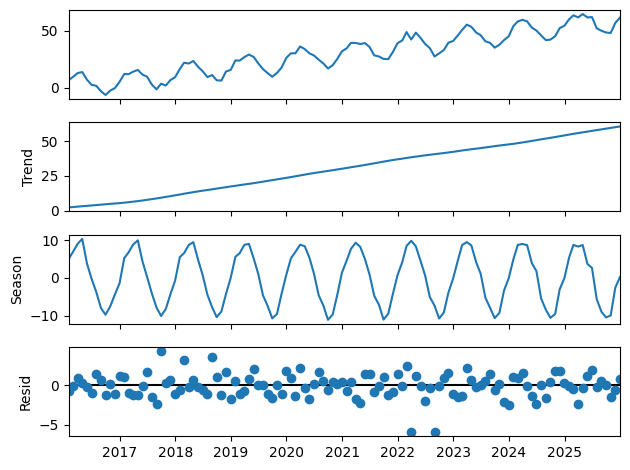

             Observed     Trend   Seasonal  Remainder
2016-01-31   6.493428  2.269279   4.982318  -0.758169
2016-02-29   9.383725  2.551316   6.878926  -0.046517
2016-03-31  12.795377  2.832938   9.045217   0.917223
2016-04-30  13.706314  3.114763  10.346735   0.244815
2016-05-31   7.031693  3.397013   3.826907  -0.192227


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 1. 가상의 항공 수요 데이터 생성 (추세 + 계절성 + 노이즈)
np.random.seed(42)
t = np.arange(1, 121)  # 10년치 월별 데이터 (120개월)
trend = 0.5 * t        # 장기적인 상승 추세
seasonal = 10 * np.sin(2 * np.pi * t / 12)  # 12개월 주기 계절성
remainder = np.random.normal(0, 2, 120)     # 잔차 (노이즈)

# 실제 관측값 (Y = T + S + R)
y = trend + seasonal + remainder
data = pd.Series(y, index=pd.date_range("2016-01-01", periods=120, freq="M"))

# 2. STL 분해 적용
# period=12: 월별 데이터이므로 주기를 12로 설정
# robust=True: 이상치에 강건하게 대응하도록 설정
stl = STL(data, period=12, robust=True)
result = stl.fit()

# 3. 결과 시각화
plt.figure(figsize=(10, 8))
result.plot()
plt.show()

# 4. 분해된 성분 확인 (추세, 계절성, 잔차 수치 추출)
df_result = pd.concat([result.observed, result.trend, result.seasonal, result.resid], axis=1)
df_result.columns = ['Observed', 'Trend', 'Seasonal', 'Remainder']
print(df_result.head())